# Esercizi

1. Crea un bar chart della percentuale media di uomini e donne nei cast dei film di ciascuna decade a partire dal file `data/academyawards.csv`.

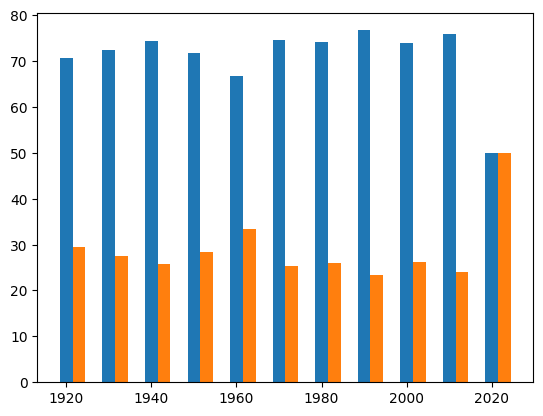

In [2]:
# ES1
import pandas as pd
import matplotlib.pyplot as plt

awards_df = pd.read_csv("data/academyawards.csv")

awards_df["total_cast"] = awards_df["male_cast"] + awards_df["female_cast"]
awards_df["female_percent"] = 100 * (awards_df["female_cast"] / awards_df["total_cast"])
awards_df["male_percent"] = 100 * (awards_df["male_cast"] / awards_df["total_cast"])

awards_df_modulo = awards_df["award_year"] % 10
awards_df_modulo

awards_df["award_decade"] = awards_df["award_year"] - awards_df_modulo

awards_df_filtered = awards_df[["award_decade", "male_percent", "female_percent"]]
grouped_df = awards_df_filtered.groupby("award_decade").mean()
grouped_df

fig, ax = plt.subplots()
ax.bar(grouped_df.index, grouped_df["male_percent"], width=3)
ax.bar(grouped_df.index +3, grouped_df["female_percent"], width=3)
plt.show()

2. Crea un grafico a torta che contiene i giorni senza precipitazioni in ciascuna delle 4 stagioni dal file `data/meteo_bologna.csv`.

In [3]:
# ES2
meteo_df = pd.read_csv("data/meteo_bologna.csv")

days_no_rain = meteo_df[meteo_df["Precipitazioni (mm)"] == 0]

# grouping by "Season" i can then count how many "Data" with no rain
days_no_rain[["Stagione", "Data"]].groupby("Stagione").count()

,Data
Stagione,
Autunno,1171
Estate,1651
Inverno,1329
Primavera,1317


3. Crea quattro box and whiskers plot che rappresentano ciascuno le temperature medie di ogni stagione.


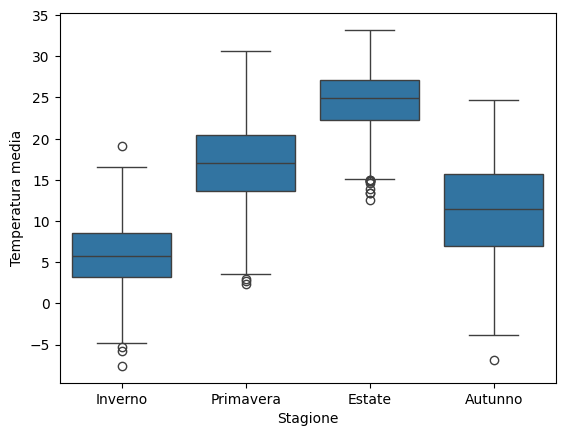

In [4]:
# ES3
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=meteo_df, x="Stagione", y="Temperatura media")
plt.show()


4. Il file `data/sport_height_weight.csv` contiene sportivi di due categorie: NBA e MotoGP. Per ciascun atleta ci sono altezza e peso. Crea uno scatterplot che contenga entrambi i gruppi con colori diversi e una legenda.


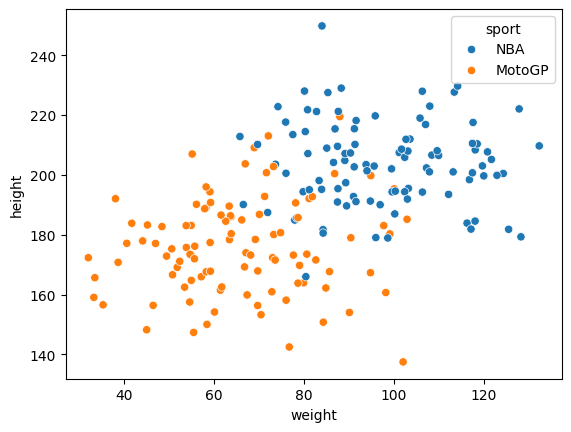

In [5]:
# ES4
sport_df = pd.read_csv("data/sport_height_weight.csv")

sns.scatterplot(data=sport_df, x="weight", y="height", hue="sport")
plt.show()


5. Apri il file `data/gutenberg/collodi-pinocchio.txt`. Ignora la prima parte del file (contiene titolo e altre informazioni) usando il numero di righe. Conta quante volte appare ciascuna parola e mostra un bar chart delle 30 parole più frequenti. Ricordati di rendere tutte le parole minuscole!


[ 13  10   3  99  47   8  96 129  45]
[1848 1389 1042 1039  965  812  742  531  514]
['e' 'di' 'che' 'a' 'il' 'un' 'la' 'in' 'per']


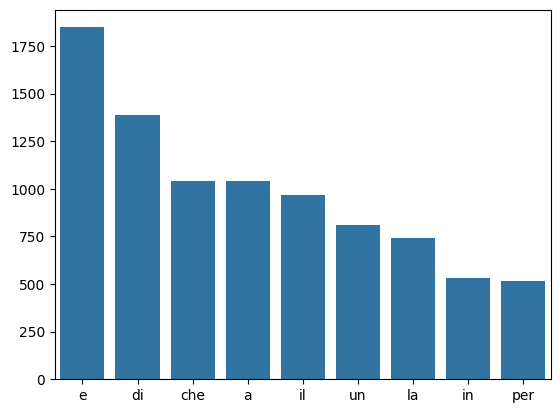

In [6]:
# ES5
import re
from collections import Counter
import numpy as np
import seaborn as sns

first_line_book = 63
pinocchio_str = ""
with open("data/gutenberg/collodi-pinocchio.txt", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        if idx < first_line_book:
            continue
        pinocchio_str += line

pinocchio_str = pinocchio_str.lower()
matches = re.findall(r"\w+", pinocchio_str)

count_words = Counter(matches)


def plot_most_common_words(words_counter):
    words = []
    counts = []
    for word, count in words_counter.items():
        words.append(word)
        counts.append(count)    
    words = np.array(words)
    counts = np.array(counts)

    ordered_indices = np.argsort(counts)[-1: -10:-1]

    sorted_counts = counts[ordered_indices[:10]]
    sorted_words = words[ordered_indices[:10]]

    print(ordered_indices[:10])
    print(counts[ordered_indices[:10]])
    print(words[ordered_indices[:10]])
    sns.barplot(x=sorted_words, y=sorted_counts)
    plt.show()

plot_most_common_words(count_words)


6. Il file `data/stopwords-it.txt` contiene le cosiddette stopwords, che sono parole molto comuni della lingua italiana (ad esempio parole grammaticali) che possono essere rimosse per consentire alcuni tipi di analisi linguistiche. Rimuovile dai token di Pinocchio e fai un grafico delle parole più frequenti rimaste.


[ 369   29  208   76 5644 5637  160  364 5639]
[460 310 208 201 178 117 113  99  94]
['pinocchio' 'è' 'burattino' 'disse' 'the' 'of' 'povero' 'casa'
 'gutenberg']


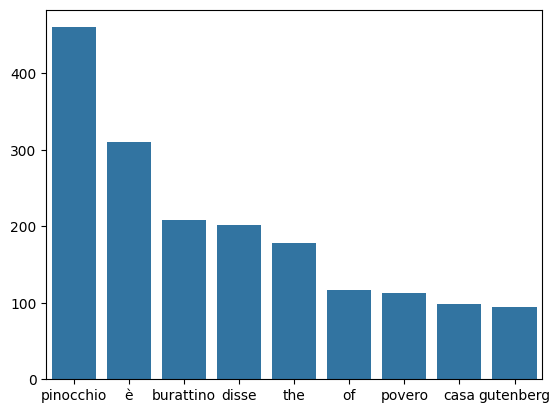

In [7]:
# ES6

with open("data/stopwords-it.txt") as f:
    for line in f:
        word = line[:-1] # remove the new line
        if word in count_words:
            del count_words[word]

plot_most_common_words(count_words)



7. Crea un grafico analogo a quello precedente ma considera **bigrammi** (sequenze di due parole). Attenzione alla punteggiatura! Visualizza il risultato tramite un bar chart dei 20 bigrammi più frequenti.


[ 1050 24053  1597  1498  2408   133  1043     9    15]
[114  86  73  63  56  56  55  54  53]
['il burattino' 'project gutenberg' 'e di' 'e il' 'e la' 'per la' 'a casa'
 'di legno' 'come un']


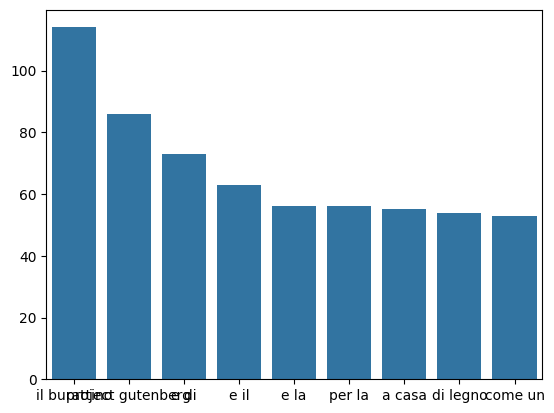

In [8]:
# ES7

# i consider periods as words to avoid considering bigrams across sentences
# if i wanted to consider all punctuation i could use string.punctuation after importing
# the "string" package
matches = re.findall(rf"\w+|\.", pinocchio_str) 

bigrams = []

for i in range(len(matches)-1):
    bigram = (matches[i], matches[i+1])
    # exclude bigrams with puctuation
    if bigram[0] == "." or bigram[1] == ".": 
        continue
    bigrams.append(" ".join(bigram))

bigrams_counter = Counter(bigrams)
plot_most_common_words(bigrams_counter)


8. Crea una lista di personaggi di Pinocchio e controlla quale personaggi appare più di frequente. Attenzione: almeno un personaggio ha un nome composito.


In [9]:
# ES8

# naif, i only look for strings
personaggi = ["geppetto", "pinocchio", 
              "maestro ciliegia", "grillo", "bambina dai capelli turchini",
              "gatto", "volpe"]

personaggi_dict = {}
for personaggio in personaggi:
    personaggi_dict[personaggio] = pinocchio_str.count(personaggio)

personaggi_df = pd.DataFrame({"personaggio": personaggi_dict.keys(), 
                              "occorrenze": personaggi_dict.values()})

personaggi_df.sort_values("occorrenze", ascending=False)

,personaggio,occorrenze
1,pinocchio,460
0,geppetto,80
6,volpe,47
5,gatto,45
3,grillo,30
2,maestro ciliegia,9
4,bambina dai capelli turchini,7


In [10]:
# more advanced: each character might have different names!

# characters with more than one names are a tuple
personaggi = ["geppetto", "pinocchio", 
              ("maestro ciliegia", "mastr'antonio"),
              "grillo", ("bambina dai capelli turchini", "fata"),
              "gatto", "volpe"]

personaggi_dict = {}
for personaggio in personaggi:
    # if the character is a tuple, it is represented by a sequence of strings 
    # separated by "|" to use in a regex
    if isinstance(personaggio, tuple):
        personaggio = "|".join(personaggio)
    personaggi_dict[personaggio] = len(re.findall(personaggio, pinocchio_str))

personaggi_for_df = [p.split("|")[0] for p in personaggi_dict.keys()]
personaggi_df = pd.DataFrame({"personaggio": personaggi_for_df, 
                              "occorrenze": personaggi_dict.values()})

personaggi_df.sort_values("occorrenze", ascending=False)

,personaggio,occorrenze
1,pinocchio,460
4,bambina dai capelli turchini,93
0,geppetto,80
6,volpe,47
5,gatto,45
3,grillo,30
2,maestro ciliegia,18



9. Crea una funzione che misura quante volte due personaggi appaiono entro 30 token l'uno dall'altro.


In [11]:
# ES9
import re
personaggi_one_name = ["geppetto", "pinocchio", 
                       "maestro ciliegia", "grillo", "bambina dai capelli turchini",
                       "gatto", "volpe"]

personaggi = ["geppetto", "pinocchio", 
              ("maestro ciliegia", "mastr'antonio"),
              "grillo", ("bambina dai capelli turchini", "fata"),
              "gatto", "volpe"]

tokenized_pinocchio = re.findall(r"\w+|\.", pinocchio_str) 

def get_personaggio_indices(personaggio, tokens):
    positions = []
    if not isinstance(personaggio, tuple):
        personaggio = [personaggio]
    for alternative_name in personaggio:
        alternative_name_tokenized = re.findall(r"\w+", alternative_name)
        
        # all the indices of tokens where the first token matches the name
        first_word_name = alternative_name_tokenized[0]
        possible_indices = [i for i,t in enumerate(tokens) if t == first_word_name]

        # check if all the tokens match the ones in the multi word names
        for possible_index in possible_indices:
            n_tokens = len(alternative_name_tokenized)
            candidate_indices = (possible_index, possible_index + n_tokens)
            candidate = " ".join(tokens[candidate_indices[0]:candidate_indices[1]])
            if candidate == alternative_name:
                positions.append(candidate_indices[0])
    return positions

positions = [get_personaggio_indices(p, tokenized_pinocchio) for p in personaggi]

def count_is_close(p1_indices, p2_indices):
    p1_begin_idx = np.array([p1idx for p1idx in p1_indices])
    p2_begin_idx = np.array([p2idx for p2idx in p2_indices])

    count_close = 0

    for p1idx in p1_indices:
        distances = np.abs(p1idx - p2_begin_idx)
        if np.any(distances < 30):
            count_close += 1
    return count_close

personaggi_close_df = pd.DataFrame(0,
                                    columns=personaggi_one_name,
                                    index=personaggi_one_name,
                                    dtype=float)


for p1_idx, p1 in enumerate(personaggi):
    p1_shortname = personaggi_one_name[p1_idx]
    for p2_idx, p2 in enumerate(personaggi):
        p2_shortname = personaggi_one_name[p2_idx]
        count_close = count_is_close(positions[p1_idx], positions[p2_idx])
        personaggi_close_df.loc[p1_shortname,p2_shortname] = count_close

personaggi_close_df

,geppetto,pinocchio,maestro ciliegia,grillo,bambina dai capelli turchini,gatto,volpe
geppetto,80.0,42.0,2.0,3.0,3.0,5.0,3.0
pinocchio,48.0,460.0,0.0,20.0,55.0,27.0,26.0
maestro ciliegia,3.0,0.0,9.0,0.0,0.0,0.0,0.0
grillo,3.0,19.0,0.0,30.0,4.0,1.0,1.0
bambina dai capelli turchini,5.0,49.0,0.0,4.0,96.0,1.0,2.0
gatto,6.0,27.0,0.0,1.0,1.0,45.0,32.0
volpe,2.0,25.0,0.0,1.0,2.0,35.0,47.0



10. Visualizza i personaggi che compaiono più volte nella stessa porzione di testo usando una heatmap.


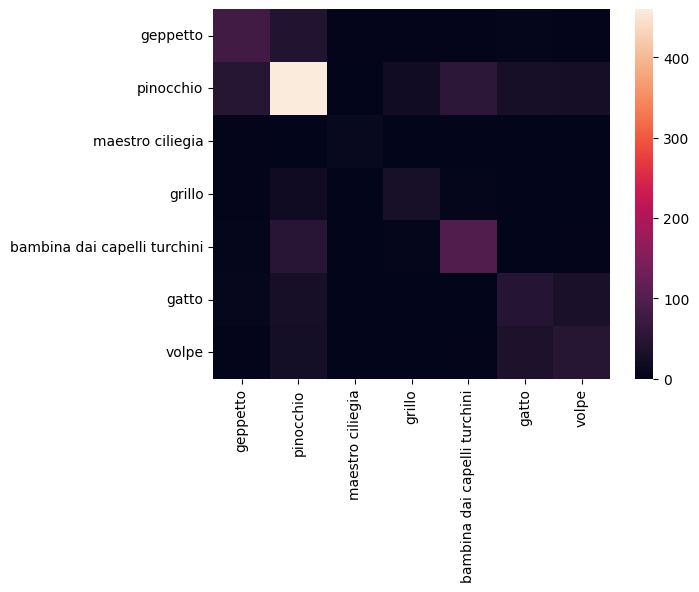

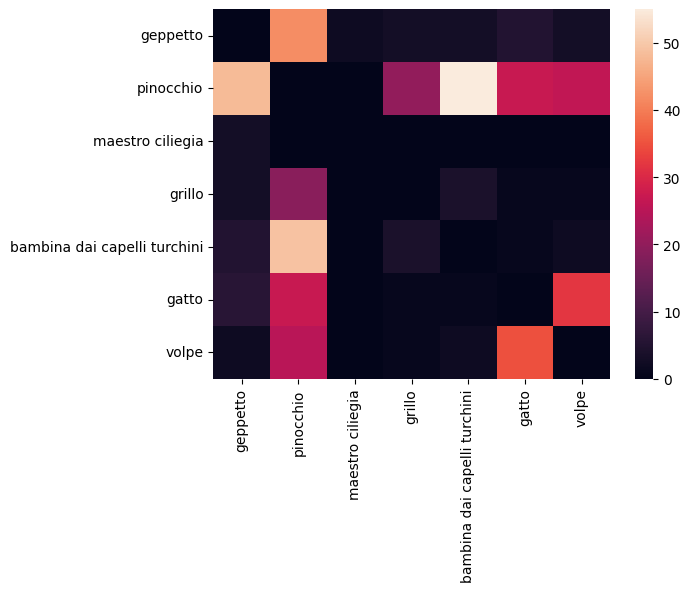

In [ ]:
# ES10

# this doesn't look great
sns.heatmap(data=personaggi_close_df)
plt.show()

# remove diagonal (eg piniocchio-pinocchio)
for personaggio in personaggi_one_name:
    personaggi_close_df.loc[personaggio, personaggio] = 0

# better
sns.heatmap(data=personaggi_close_df)
plt.show()